[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/carlos-argueta/factor-graphs-from-scratch/blob/main/modules/05-incremental-sparse/lesson.ipynb)

# Module 5 — Incremental & sparse solving

> **Goal.** The batch solver from M4 forms the full system and factorises it *from scratch every iteration*. That is fine for a handful of poses and hopeless for a real trajectory. This module rebuilds the solve around the one structural fact we have been ignoring: **the problem is sparse**. We will (1) see why a dense solve does not scale, (2) build **variable elimination** — the sparse factorisation that GTSAM and iSAM2 actually run — as an operation on the graph, (3) find a good **elimination order** and read off the **Bayes tree** it induces, and then (4) use that structure to **marginalise** old variables (fixed-lag smoothing) and (5) **update incrementally** as new measurements arrive, out of order. By the end the phrase *"iSAM2 maintains a Bayes tree and relinearises fluidly"* describes something you have built.


### A refresher: the linear system inside Gauss–Newton

Every M1–M4 solve did the same thing each iteration: linearise the factors at the current estimate to get a stacked residual $r$ and Jacobian $J$, then take the step that minimises $\|J\delta + r\|^2$. That step solves the **normal equations**

$$\underbrace{J^\top J}_{\Lambda}\,\delta \;=\; \underbrace{-J^\top r}_{\eta}, \qquad \Lambda\,\delta = \eta.$$

$\Lambda$ is the **information matrix** (symmetric, positive-definite); $\eta$ is the information vector. On a manifold nothing changes here — $\delta$ is a tangent vector and we retract with $\boxplus$ afterwards (M4). M4 solved $\Lambda\delta=\eta$ with a **dense** factorisation that ignores the structure of $\Lambda$. This module is about that structure. From here on we work one linearisation at a time and study how to solve $\Lambda\delta=\eta$ *well*; the outer $\boxplus$ loop wrapping it is unchanged.


In [1]:
import sys, pathlib, subprocess
import numpy as np

# --- Colab bootstrap -------------------------------------------------------
# On Google Colab the repository isn't present, so clone it once to make the
# course packages (`gaussian_filters`, `factorgraph`) importable.
REPO_URL = "https://github.com/carlos-argueta/factor-graphs-from-scratch.git"
if "google.colab" in sys.modules:
    repo = pathlib.Path("/content/factor-graphs-from-scratch")
    if not repo.exists():
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, str(repo)], check=True)
    if str(repo / "src") not in sys.path:
        sys.path.insert(0, str(repo / "src"))

# --- Local: put the repo's src/ on the path (covers gaussian_filters + factorgraph)
def _add_src_to_path():
    here = pathlib.Path.cwd().resolve()
    for base in [here, *here.parents]:
        if (base / "src" / "factorgraph").exists():
            if str(base / "src") not in sys.path:
                sys.path.insert(0, str(base / "src"))
            return
_add_src_to_path()

np.set_printoptions(precision=5, suppress=True)

In [2]:
import matplotlib.pyplot as plt

# palette (light surface) + recessive chrome  — shared with M0–M4
BLUE, AQUA, VIOLET, RED = "#2a78d6", "#1baf7a", "#4a3aa7", "#e34948"
INK, MUTED, GRID = "#0b0b0b", "#898781", "#e1e0d9"

def _style(ax, title):
    ax.set_title(title, color=INK, fontsize=11, pad=8)
    ax.grid(True, color=GRID, lw=0.8)
    ax.set_axisbelow(True)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color(MUTED)
    ax.tick_params(colors=MUTED, labelsize=8)

## 1 · Why the dense solve doesn't scale

We reuse the M4 engine — imported now from `factorgraph`, since M4 is done — and build a pose graph: a trajectory of `Pose2` variables tied by odometry `BetweenFactor`s, a `PriorFactor` anchoring the start, and a **loop closure** when the robot returns to where it began.

In [3]:
from factorgraph import Pose2, se2_exp, PriorFactor, BetweenFactor, FactorGraph, Ordering

rng = np.random.default_rng(2)
K = 10                                             # poses along one closed loop

# ground truth: drive a rounded loop that comes back to the origin
gt = [Pose2(0.0, 0.0, 0.0)]
for _ in range(K - 1):
    gt.append(gt[-1].retract([1.0, 0.0, 2 * np.pi / (K - 1)]))   # equal turns -> a polygon

odo_sigma = [0.04, 0.04, np.deg2rad(2.0)]
meas = [Pose2(T=se2_exp(gt[k].local(gt[k + 1]) + rng.normal(scale=odo_sigma))) for k in range(K - 1)]

def pose_graph(loop=True):
    g = FactorGraph()
    g.add(PriorFactor(0, Pose2(0, 0, 0), sigma=[1e-2, 1e-2, 1e-2]))
    for k in range(K - 1):
        g.add(BetweenFactor(k, k + 1, meas[k], sigma=odo_sigma))
    if loop:                                        # the robot recognises the start
        g.add(BetweenFactor(K - 1, 0, gt[K - 1].between(gt[0]), sigma=[0.05, 0.05, np.deg2rad(3)]))
    return g

values = {k: gt[k] for k in range(K)}              # linearise near the truth (small residual)

def system(graph, values):
    """Linearise the graph -> information matrix Lambda = J^T J and vector eta = -J^T r."""
    ordering = Ordering({k: v.dof for k, v in values.items()})
    r, J = graph.linearize(values, ordering)
    return J.T @ J, -J.T @ r, ordering.slices

Lam, eta, slices = system(pose_graph(), values)
print(f"{K} poses x 3 dof  ->  Lambda is {Lam.shape[0]}x{Lam.shape[1]}, "
      f"{100 * np.mean(np.abs(Lam) > 1e-12):.0f}% of its entries are non-zero")

10 poses x 3 dof  ->  Lambda is 30x30, 29% of its entries are non-zero


$\Lambda$ is **block-sparse**, and the pattern is a picture of the graph: a $3\times3$ block $(i,j)$ is non-zero **iff some factor touches both pose $i$ and pose $j$**. Odometry fills the block-diagonal and its neighbours (a band); the prior adds to block $(0,0)$; the loop closure puts a block far off the diagonal, at $(0, K\!-\!1)$. Most of the matrix is exactly zero.

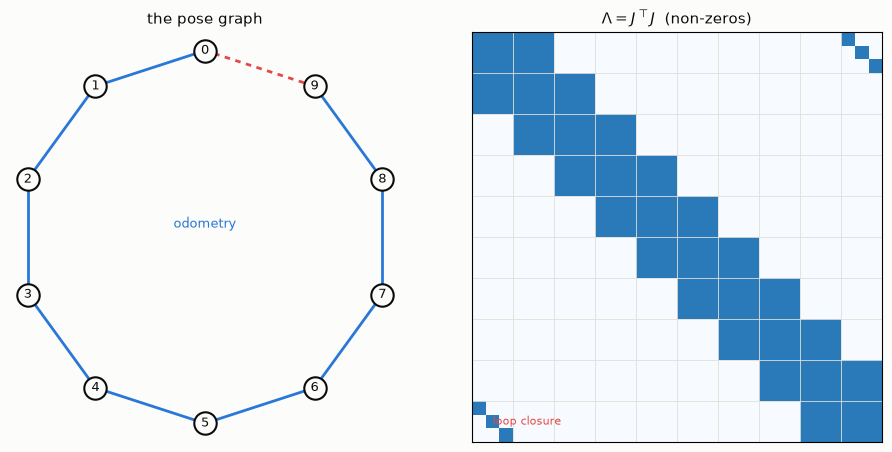

In [4]:
fig, (axg, axm) = plt.subplots(1, 2, figsize=(9.6, 4.6), facecolor="#fcfcfb")

# --- left: the factor graph as a ring of poses + the loop-closure chord ---
ang = np.linspace(0, 2 * np.pi, K, endpoint=False) + np.pi / 2
px, py = np.cos(ang), np.sin(ang)
for k in range(K - 1):
    axg.plot([px[k], px[k + 1]], [py[k], py[k + 1]], color=BLUE, lw=2, zorder=1)
axg.plot([px[K - 1], px[0]], [py[K - 1], py[0]], color=RED, lw=2, ls=(0, (2, 2)), zorder=1)
axg.scatter(px, py, s=260, color="#fcfcfb", edgecolor=INK, lw=1.5, zorder=2)
for k in range(K):
    axg.annotate(str(k), (px[k], py[k]), ha="center", va="center", color=INK, fontsize=9, zorder=3)
axg.annotate("odometry", (0, 0.05), color=BLUE, ha="center", fontsize=9)
axg.annotate("loop closure", (px[0] * 0.5, py[0] * 1.15), color=RED, ha="center", fontsize=8)
axg.set_aspect("equal"); axg.axis("off"); axg.set_title("the pose graph", color=INK, fontsize=11)

# --- right: the information matrix Lambda has that same connectivity ---
axm.imshow(np.abs(Lam) > 1e-12, cmap="Blues", vmin=0, vmax=1.4)
for s in range(0, 3 * K + 1, 3):                    # 3x3 block grid lines
    axm.axhline(s - 0.5, color=GRID, lw=0.6); axm.axvline(s - 0.5, color=GRID, lw=0.6)
axm.set_title(r"$\Lambda = J^\top J$  (non-zeros)", color=INK, fontsize=11)
axm.set_xticks([]); axm.set_yticks([])
axm.annotate("loop closure", (1, 3 * (K - 1) + 1), color=RED, fontsize=8, va="center")
plt.tight_layout(); plt.show()

A **dense** Cholesky of $\Lambda$ costs $O(n^3)$ time and $O(n^2)$ memory in the number of scalar unknowns $n = 3K$. At $K=10$ that is nothing; at $K=10^5$ poses it is $\sim10^{15}$ operations and terabytes — per iteration. But $\Lambda$ has $O(K)$ non-zeros, not $O(K^2)$. The entire game is to factorise it **without destroying that sparsity**. The tool is variable elimination — and its one hazard is **fill-in**, new non-zeros created during factorisation, which §3 shows how to control.

## 2 · Variable elimination

**The idea.** Instead of inverting $\Lambda$ whole, remove one variable at a time. To *eliminate* variable $x_v$: collect every term involving it, solve for $x_v$ **as a function of its neighbours** (a conditional), and substitute that back — leaving a smaller system on the remaining variables. Do this for all variables and you have factorised $\Lambda$; back-substitute in reverse to recover $\delta$. Here is that step, in full.

**The partitioned system.** Split the unknowns into three groups: the variable being eliminated $x_v$, its **neighbours** $x_N$ (everything that shares a factor with $x_v$), and the **rest** $x_R$. In that ordering, $\Lambda\delta=\eta$ has the block structure

$$\begin{bmatrix}\Lambda_{vv} & \Lambda_{vN} & \mathbf{0}\\[2pt] \Lambda_{Nv} & \Lambda_{NN} & \Lambda_{NR}\\[2pt] \mathbf{0} & \Lambda_{RN} & \Lambda_{RR}\end{bmatrix}\begin{bmatrix}\delta_v\\[2pt] \delta_N\\[2pt] \delta_R\end{bmatrix}=\begin{bmatrix}\eta_v\\[2pt] \eta_N\\[2pt] \eta_R\end{bmatrix}.$$

The top-right and bottom-left blocks are **exactly zero**. Recall from §1 that a block $(i,j)$ of $\Lambda$ is non-zero only if some factor touches both variables; by definition the rest $x_R$ shares no factor with $x_v$, so $\Lambda_{vR}=\Lambda_{Rv}^{\top}=\mathbf{0}$. That one structural fact is what makes elimination *local*.

**Reading off the rows.** Carry out the block multiplication one row-band at a time and the matrix equation separates into three:

$$\begin{aligned}
\text{(v)}\quad & \Lambda_{vv}\,\delta_v + \Lambda_{vN}\,\delta_N + \mathbf{0}\,\delta_R = \eta_v,\\
\text{(N)}\quad & \Lambda_{Nv}\,\delta_v + \Lambda_{NN}\,\delta_N + \Lambda_{NR}\,\delta_R = \eta_N,\\
\text{(R)}\quad & \mathbf{0}\,\delta_v + \Lambda_{RN}\,\delta_N + \Lambda_{RR}\,\delta_R = \eta_R.
\end{aligned}$$

The zeros pay off immediately: $\delta_R$ drops out of row (v), and $\delta_v$ drops out of row (R). So $x_v$ couples **only** to its neighbours, and eliminating it can touch $x_N$ but never the far-away $x_R$.

**The conditional.** Solve row (v) for $x_v$ in terms of its neighbours — this is what back-substitution will use, once $\delta_N$ is known, so we store it:

$$\delta_v = \Lambda_{vv}^{-1}\big(\eta_v - \Lambda_{vN}\,\delta_N\big).$$

**Substitute to remove $x_v$.** Put that expression into row (N) in place of $\delta_v$:

$$\Lambda_{Nv}\,\Lambda_{vv}^{-1}\big(\eta_v - \Lambda_{vN}\delta_N\big) + \Lambda_{NN}\,\delta_N + \Lambda_{NR}\,\delta_R = \eta_N.$$

Expand the product, then gather the $\delta_N$ terms on the left and move the constant $\eta_v$ term to the right:

$$\big(\Lambda_{NN} - \Lambda_{Nv}\Lambda_{vv}^{-1}\Lambda_{vN}\big)\,\delta_N + \Lambda_{NR}\,\delta_R = \eta_N - \Lambda_{Nv}\Lambda_{vv}^{-1}\eta_v.$$

Row (R) never mentioned $x_v$, so it is unchanged. Rows (N) and (R) are now a complete system over the *remaining* variables with $x_v$ gone — and the only block that changed is the neighbour block, overwritten by the **Schur complement**

$$\boxed{\;\Lambda_{NN} \leftarrow \Lambda_{NN} - \Lambda_{Nv}\Lambda_{vv}^{-1}\Lambda_{vN}\,,\qquad \eta_N \leftarrow \eta_N - \Lambda_{Nv}\Lambda_{vv}^{-1}\eta_v\;}$$

leaving $\Lambda_{NR}$, $\Lambda_{RR}$, and $\eta_R$ untouched. That one rank-correcting subtraction — a term for each pair of neighbours — is the whole algorithm; repeat it down the elimination order and $\Lambda$ is factorised. (It is exactly block Cholesky, seen through the graph; Appendix A makes the equivalence explicit.)

In [5]:
def eliminate(Lam, eta, slices, order):
    """Solve Lambda @ delta = eta by variable elimination in the given order.
    Returns delta plus the conditionals (the Bayes net) produced along the way."""
    L, e = Lam.copy(), eta.copy()
    active = set(order)
    conditionals = []                                     # (v, Avv^{-1}, {neighbour: block}, eta_v)
    for v in order:
        sv = slices[v]
        neigh = [u for u in active if u != v and np.any(L[sv, slices[u]])]
        Ainv = np.linalg.inv(L[sv, sv])
        conditionals.append((v, Ainv, {u: L[sv, slices[u]].copy() for u in neigh}, e[sv].copy()))
        for u in neigh:                                   # Schur complement onto the neighbours
            Luv = L[slices[u], sv]
            e[slices[u]] -= Luv @ Ainv @ e[sv]
            for w in neigh:
                L[slices[u], slices[w]] -= Luv @ Ainv @ L[sv, slices[w]]
        active.discard(v)
    delta = np.zeros_like(eta)                            # back-substitution, in reverse order
    for v, Ainv, coup, ev in reversed(conditionals):
        s = ev.copy()
        for u, Lvu in coup.items():
            s -= Lvu @ delta[slices[u]]
        delta[slices[v]] = Ainv @ s
    return delta, conditionals

delta_elim, conds = eliminate(Lam, eta, slices, order=list(range(K)))
delta_dense = np.linalg.solve(Lam, eta)
print("elimination vs dense solve — max difference:", np.max(np.abs(delta_elim - delta_dense)))
assert np.allclose(delta_elim, delta_dense, atol=1e-9)
print("identical to machine precision: elimination *is* the solve, done sparsely.")

elimination vs dense solve — max difference: 1.3183898417423734e-16
identical to machine precision: elimination *is* the solve, done sparsely.


**The graph view — where fill-in is born.** Eliminating $x_v$ deletes it and connects **all of its neighbours to each other** (they now share the new Schur-complement term — a factor over $x_N$). If $x_v$'s neighbours were not already mutually connected, those new edges are **fill-in**: non-zeros that were not in $\Lambda$. Eliminate a variable with few neighbours and you add almost nothing; eliminate a **highly connected** one and you create a large dense block. The order in which you eliminate therefore decides how much fill-in — and how much work — the factorisation costs. The figure below shows one such fill-in appearing on our own $\Lambda$; keeping the *number* of these small is the subject of §3.

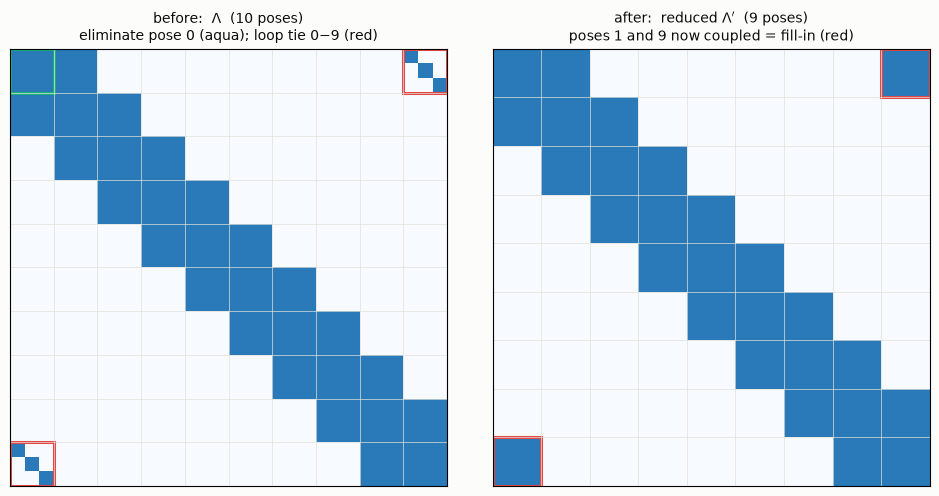

pose 0's neighbours were [1, 9]; eliminating it left them directly coupled -> exactly one fill-in block, and the rest of the reduced system stayed sparse.


In [6]:
from matplotlib.patches import Rectangle
tol = 1e-12

# eliminate pose 0 with a single Schur step -> reduced information matrix over poses 1..K-1
sv = slices[0]
neigh0 = [u for u in range(1, K) if np.any(np.abs(Lam[sv, slices[u]]) > tol)]
A0inv = np.linalg.inv(Lam[sv, sv])
Lr = Lam.copy()
for u in neigh0:
    for w in neigh0:                                  # Schur complement onto pose 0's neighbours
        Lr[slices[u], slices[w]] -= Lam[slices[u], sv] @ A0inv @ Lam[sv, slices[w]]
keep = list(range(1, K))
idx = np.r_[tuple(np.r_[slices[k]] for k in keep)]
Lam_red = Lr[np.ix_(idx, idx)]                        # drop pose 0's row/column

def blk(ax, bi, bj, color, lw=2.2):                  # outline the 3x3 block at (bi, bj)
    ax.add_patch(Rectangle((bj * 3 - 0.5, bi * 3 - 0.5), 3, 3, fill=False, edgecolor=color, lw=lw))

fig, (axA, axB) = plt.subplots(1, 2, figsize=(9.8, 4.9), facecolor="#fcfcfb")

# --- before: the full Lambda, with pose 0 (to be eliminated) and its loop coupling marked ---
axA.imshow(np.abs(Lam) > tol, cmap="Blues", vmin=0, vmax=1.4)
for s in range(0, 3 * K + 1, 3):
    axA.axhline(s - 0.5, color=GRID, lw=0.5); axA.axvline(s - 0.5, color=GRID, lw=0.5)
blk(axA, 0, 0, AQUA)                                  # pose 0 (eliminated)
blk(axA, 0, K - 1, RED); blk(axA, K - 1, 0, RED)      # loop closure ties pose 0 to pose 9
axA.set_title(r"before:  $\Lambda$  (10 poses)"
              "\neliminate pose 0 (aqua); loop tie 0$-$9 (red)", color=INK, fontsize=10)
axA.set_xticks([]); axA.set_yticks([])

# --- after: the reduced Lambda'; the new 1<->9 block is fill-in ---
axB.imshow(np.abs(Lam_red) > tol, cmap="Blues", vmin=0, vmax=1.4)
for s in range(0, 3 * (K - 1) + 1, 3):
    axB.axhline(s - 0.5, color=GRID, lw=0.5); axB.axvline(s - 0.5, color=GRID, lw=0.5)
blk(axB, 0, K - 2, RED); blk(axB, K - 2, 0, RED)      # poses 1 and 9 -> reduced indices 0 and 8
axB.set_title(r"after:  reduced $\Lambda'$  (9 poses)"
              "\nposes 1 and 9 now coupled = fill-in (red)", color=INK, fontsize=10)
axB.set_xticks([]); axB.set_yticks([])
plt.tight_layout(); plt.show()

print(f"pose 0's neighbours were {neigh0}; eliminating it left them directly coupled "
      "-> exactly one fill-in block, and the rest of the reduced system stayed sparse.")

## 3 · Elimination order and the Bayes tree

**Ordering decides fill-in.** Take the worst case for intuition: one variable tied to many others — a landmark seen from everywhere, or a spot the robot revisits again and again (a *hub*). Here poses $\{3,4,5,6,7\}$ all connect back to pose $0$:

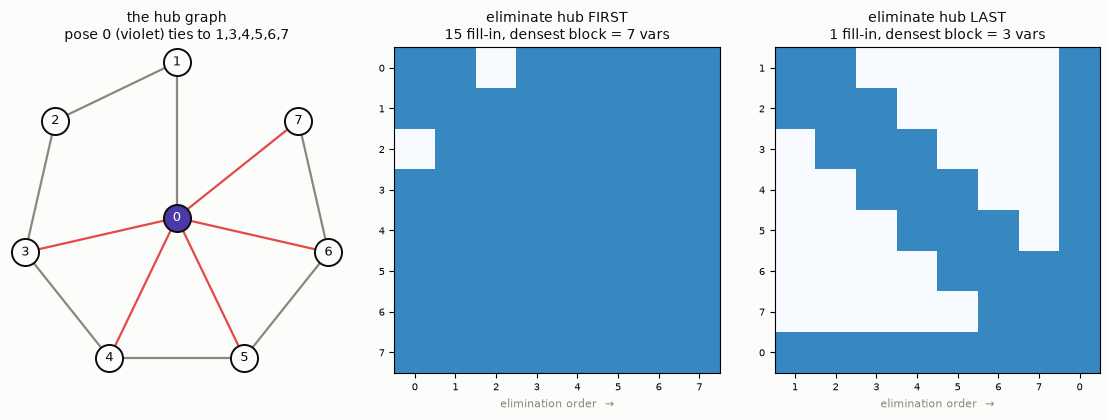

pose 0 shares a factor with [1, 3, 4, 5, 6, 7] — 6 neighbours.
  eliminate it FIRST: its neighbours all fuse -> 15 fill-in edges, a dense 7-variable block (left matrix).
  eliminate it LAST : almost nothing fuses    -> 1 fill-in edge,   densest block only 3 variables (right matrix).


In [7]:
def var_adjacency(graph, keys):
    """Which variables share a factor — the graph the information matrix encodes."""
    adj = {k: set() for k in keys}
    for f in graph.factors:
        for a in f.keys:
            for b in f.keys:
                if a != b:
                    adj[a].add(b); adj[b].add(a)
    return adj

def symbolic_fill(adj, order):
    """Simulate elimination on the graph: return (#fill-in edges added, largest clique size)."""
    adj = {k: set(v) for k, v in adj.items()}
    active, fill, biggest = set(order), 0, 1
    for v in order:
        neigh = [u for u in adj[v] if u in active]
        biggest = max(biggest, len(neigh) + 1)
        for i in range(len(neigh)):
            for j in range(i + 1, len(neigh)):
                a, b = neigh[i], neigh[j]
                if b not in adj[a]:
                    adj[a].add(b); adj[b].add(a); fill += 1
        active.discard(v)
    return fill, biggest

def filled_pattern(adj, order):
    """The sparsity pattern the factorisation ends with, for a given elimination order
    (1 where variables are connected, including fill-in edges added during elimination)."""
    adj = {k: set(v) for k, v in adj.items()}; active = set(order)
    pos = {v: i for i, v in enumerate(order)}
    P = np.eye(len(order))
    for v in order:
        neigh = [u for u in adj[v] if u in active]
        for a in neigh + [v]:
            for b in neigh + [v]:
                P[pos[a], pos[b]] = 1
        for i in range(len(neigh)):
            for j in range(i + 1, len(neigh)):
                adj[neigh[i]].add(neigh[j]); adj[neigh[j]].add(neigh[i])
        active.discard(v)
    return P

# a hub graph: a chain 0-1-...-7, plus pose 0 revisited from 3,4,5,6,7 (loop closures)
H = 8
hub = {k: set() for k in range(H)}
def _e(a, b): hub[a].add(b); hub[b].add(a)
for i in range(H - 1): _e(i, i + 1)                   # odometry chain
for j in [3, 4, 5, 6, 7]: _e(0, j)                    # revisits -> pose 0 is a hub

first = [0] + list(range(1, H))                       # eliminate the hub first
last  = list(range(1, H)) + [0]                       # eliminate the hub last
f_first, c_first = symbolic_fill(hub, first)
f_last,  c_last  = symbolic_fill(hub, last)

# ---- the graph, and the matrix each elimination order leaves behind ---------------
fig = plt.figure(figsize=(11.4, 3.9), facecolor="#fcfcfb")
axG, ax1, ax2 = (fig.add_subplot(1, 3, i) for i in (1, 2, 3))

ang = np.linspace(0, 2 * np.pi, H - 1, endpoint=False) + np.pi / 2   # poses 1..7 on a ring
pos = {0: (0.0, 0.0)}
for i, j in enumerate(range(1, H)):
    pos[j] = (np.cos(ang[i]), np.sin(ang[i]))
drawn = set()
for a in hub:
    for b in hub[a]:
        if (b, a) in drawn: continue
        drawn.add((a, b))
        spoke = (0 in (a, b)) and (max(a, b) in (3, 4, 5, 6, 7))     # a revisit edge
        axG.plot([pos[a][0], pos[b][0]], [pos[a][1], pos[b][1]],
                 color=RED if spoke else MUTED, lw=1.6, zorder=1)
for k in hub:
    axG.scatter(*pos[k], s=380, color=VIOLET if k == 0 else "#fcfcfb",
                edgecolor=INK, lw=1.4, zorder=2)
    axG.annotate(str(k), pos[k], ha="center", va="center",
                 color="white" if k == 0 else INK, fontsize=9, zorder=3)
axG.set_title("the hub graph\npose 0 (violet) ties to 1,3,4,5,6,7", color=INK, fontsize=10)
axG.set_aspect("equal"); axG.axis("off")

for ax, order, ttl, f, c in [(ax1, first, "eliminate hub FIRST", f_first, c_first),
                             (ax2, last,  "eliminate hub LAST",  f_last,  c_last)]:
    ax.imshow(filled_pattern(hub, order), cmap="Blues", vmin=0, vmax=1.5)
    ax.set_title(f"{ttl}\n{f} fill-in, densest block = {c} vars", color=INK, fontsize=10)
    ax.set_xticks(range(H)); ax.set_yticks(range(H))
    ax.set_xticklabels(order, fontsize=7.5); ax.set_yticklabels(order, fontsize=7.5)
    ax.set_xlabel("elimination order  →", color=MUTED, fontsize=8)
plt.tight_layout(); plt.show()

print(f"pose 0 shares a factor with {sorted(hub[0])} — {len(hub[0])} neighbours.")
print(f"  eliminate it FIRST: its neighbours all fuse -> {f_first} fill-in edges, "
      f"a dense {c_first}-variable block (left matrix).")
print(f"  eliminate it LAST : almost nothing fuses    -> {f_last} fill-in edge,   "
      f"densest block only {c_last} variables (right matrix).")

As the two matrices above show, eliminating the hub **first** merges all its neighbours into one dense clique — lots of fill, a big dense block to factorise. Eliminating it **last** costs almost nothing. Finding a good order is its own (NP-hard) problem, but cheap greedy heuristics work extremely well; the standard one, **minimum degree** (GTSAM uses COLAMD), repeatedly eliminates the currently least-connected variable:

In [8]:
def min_degree_order(adj):
    """Greedy minimum-degree ordering: repeatedly eliminate the least-connected variable."""
    adj = {k: set(v) for k, v in adj.items()}
    active, order = set(adj), []
    while active:
        v = min(active, key=lambda k: len(adj[k] & active))
        order.append(v)
        nl = [u for u in adj[v] if u in active and u != v]
        for i in range(len(nl)):                          # eliminating v cliques its neighbours
            for j in range(i + 1, len(nl)):
                adj[nl[i]].add(nl[j]); adj[nl[j]].add(nl[i])
        active.discard(v)
    return order

md_order = min_degree_order(hub)
f_md, c_md = symbolic_fill(hub, md_order)
print("min-degree order:", md_order)
print(f"  -> {f_md} fill-in edge, densest block {c_md} vars: it recovers the good order")
print("     automatically, eliminating the hub (pose 0) late without being told it is special.")

min-degree order: [1, 2, 3, 4, 5, 0, 6, 7]
  -> 1 fill-in edge, densest block 3 vars: it recovers the good order
     automatically, eliminating the hub (pose 0) late without being told it is special.


**The Bayes tree.** Everything so far was linear algebra, but the very same elimination has a *probabilistic* reading — and that reading is the data structure iSAM2 actually stores. Four short steps get us there.

**1 · The linear system is a Gaussian.** In M2 we wrote a Gaussian in **information form**, $p(x)\propto\exp\!\big(-\tfrac12\,x^\top\Lambda x + \eta^\top x\big)$, with information matrix $\Lambda$ and information vector $\eta$. That is *exactly* the $\Lambda,\eta$ we have been eliminating: expanding $\tfrac12\|J\delta+r\|^2 = \tfrac12\delta^\top\Lambda\delta - \eta^\top\delta + \text{const}$ shows that minimising the whitened least-squares cost is the same as maximising $p(\delta)\propto\exp\!\big(-\tfrac12\delta^\top\Lambda\delta+\eta^\top\delta\big)$. So the "probabilities" are not new machinery — the residuals were whitened, so $-\tfrac12\|\cdot\|^2$ *is* a Gaussian log-probability, and $\Lambda\delta=\eta$ is a **joint Gaussian over all the poses**. The factor graph is a picture of how that joint splits into one piece per measurement.

**2 · A one-minute Bayes-net refresher.** A **Bayes net** is a *directed* graph in which each variable carries a conditional distribution given its parents, and the joint is the product of those conditionals:

$$p(x_1,\dots,x_n)=\prod_i p\big(x_i \mid \mathrm{parents}(x_i)\big),\qquad\text{e.g.}\quad p(a,b,c)=p(a\mid b,c)\,p(b\mid c)\,p(c).$$

An arrow runs from each parent to its child; reading the factors right-to-left is a generative recipe (draw $c$, then $b$ given $c$, then $a$ given $b,c$). Where a *factor graph* is undirected and says "here are the measurements," a *Bayes net* is directed and says "here is the joint, already factored so you can solve it in one sweep."

**3 · Elimination turns the factor graph into a Bayes net.** Look again at one elimination step (§2). Removing $x_v$ produced $\delta_v=\Lambda_{vv}^{-1}(\eta_v-\Lambda_{vN}\delta_N)$ — $x_v$ written as a linear-Gaussian function of the neighbours it still touched. **That expression is the conditional $p(x_v\mid x_N)$**: a Gaussian whose mean slides with $x_N$. Do this for every variable in the elimination order and you get one conditional apiece — $p(x_{v_1}\mid x_{N_1}),\ p(x_{v_2}\mid x_{N_2}),\ \dots$ — ending with the last variable's plain marginal (it has no neighbours left), and their product *is* the joint again. **That ordered list of conditionals is the "sequence" from the header, and together they form a Bayes net**, in which $x_v$'s parents are precisely the neighbours $x_N$ it was conditioned on. A good order (few live neighbours at elimination time) therefore means few parents — and little fill-in.

**4 · Cliques, and why it collapses to a *tree*.** Because elimination adds fill-in edges, consecutive conditionals overlap — they share variables. Bundle each variable together with the neighbours it was conditioned on into a **clique** (a set of variables that are all mutually connected in the filled graph, i.e. that appear together in one conditional). The conditionals then nest into a **tree of cliques**, each clique conditioned on the one above it: the **Bayes tree**. A clique's parent is the clique holding the first of its variables to be eliminated further up the order. That tree shape is the whole point — adding a measurement only disturbs the cliques between the touched variables and the root, so updates stay local (§5).

Below: first the three views of one model on a bare 4-pose chain — **factor graph → Bayes net → Bayes tree** — then the Bayes tree of our actual loop-closing pose graph.

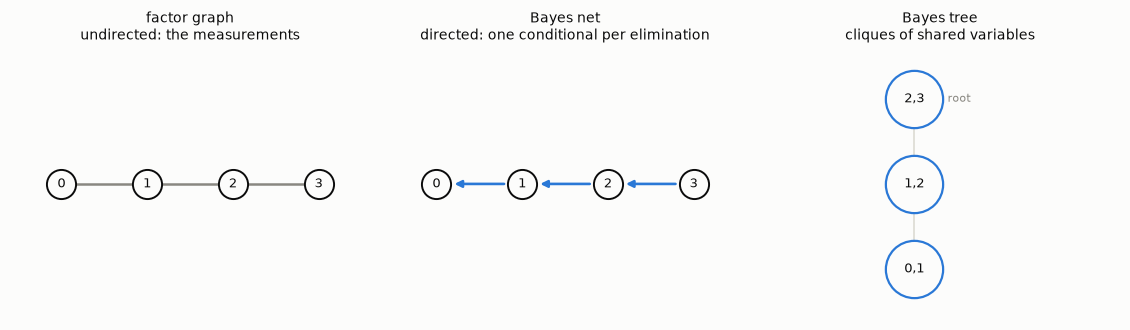

eliminating 0,1,2,3 gives p(0|1) p(1|2) p(2|3) p(3): a directed chain, then cliques {0,1}<-{1,2}<-{2,3}.


In [9]:
# One model, three faces, on a bare 4-pose chain (no loop closure, so no fill-in).
chain = [0, 1, 2, 3]
fig, (a1, a2, a3) = plt.subplots(1, 3, figsize=(11.4, 3.4), facecolor="#fcfcfb")
xy = {k: (float(k), 0.0) for k in chain}

def _nodes(ax, pts):
    for k, p in pts.items():
        ax.scatter(*p, s=440, color="#fcfcfb", edgecolor=INK, lw=1.4, zorder=3)
        ax.annotate(str(k), p, ha="center", va="center", color=INK, fontsize=9.5, zorder=4)

# 1) factor graph: undirected edges are the measurements tying poses together
for k in range(3):
    a1.plot([k, k + 1], [0, 0], color=MUTED, lw=1.8, zorder=1)
_nodes(a1, xy)
a1.set_title("factor graph\nundirected: the measurements", color=INK, fontsize=10)

# 2) Bayes net: eliminate 0,1,2,3 -> each step is p(v | its remaining neighbour); arrow parent->child
for child, parent in [(0, 1), (1, 2), (2, 3)]:
    a2.annotate("", xy=xy[child], xytext=xy[parent],
                arrowprops=dict(arrowstyle="-|>", color=BLUE, lw=1.9, shrinkA=13, shrinkB=13))
_nodes(a2, xy)
a2.set_title("Bayes net\ndirected: one conditional per elimination", color=INK, fontsize=10)

# 3) Bayes tree: bundle each variable with the neighbour it was conditioned on -> cliques
cliques = [(0, 1), (1, 2), (2, 3)]              # {0,1} leaf ... {2,3} root
cxy = {c: (0.0, float(i)) for i, c in enumerate(cliques)}
for i in range(2):
    a3.plot([0, 0], [i, i + 1], color=GRID, lw=1.4, zorder=1)
for c, p in cxy.items():
    a3.scatter(*p, s=1700, color="#fcfcfb", edgecolor=BLUE, lw=1.6, zorder=2)
    a3.annotate(",".join(map(str, c)), p, ha="center", va="center", color=INK, fontsize=9.5, zorder=3)
a3.annotate("root", cxy[(2, 3)], textcoords="offset points", xytext=(24, 0),
            color=MUTED, fontsize=8, va="center")
a3.set_title("Bayes tree\ncliques of shared variables", color=INK, fontsize=10)

for ax in (a1, a2, a3):
    ax.axis("off")
a1.set_xlim(-0.6, 3.6); a1.set_ylim(-1.1, 1.1)
a2.set_xlim(-0.6, 3.6); a2.set_ylim(-1.1, 1.1)
a3.set_xlim(-1.2, 1.6); a3.set_ylim(-0.6, 2.6)
plt.tight_layout(); plt.show()
print("eliminating 0,1,2,3 gives p(0|1) p(1|2) p(2|3) p(3): a directed chain, then cliques {0,1}<-{1,2}<-{2,3}.")

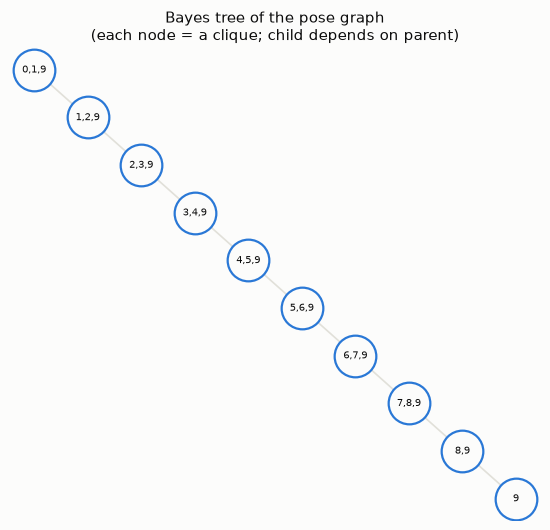

loop closure threads pose 0 up through the tree — that's why it couples distant poses.


In [10]:
def bayes_tree(adj, order):
    """Return {frontal_variable: (clique_variables, parent_frontal)} for the elimination order."""
    adj = {k: set(v) for k, v in adj.items()}
    active, pos = set(order), {v: i for i, v in enumerate(order)}
    tree = {}
    for v in order:
        neigh = {u for u in adj[v] if u in active and u != v}
        parent = min(neigh, key=lambda u: pos[u]) if neigh else None
        tree[v] = (tuple(sorted({v} | neigh)), parent)
        nl = list(neigh)
        for i in range(len(nl)):
            for j in range(i + 1, len(nl)):
                adj[nl[i]].add(nl[j]); adj[nl[j]].add(nl[i])
        active.discard(v)
    return tree

# build the Bayes tree of OUR pose graph (chain + one loop closure)
adjG = var_adjacency(pose_graph(), list(range(K)))
orderG = list(range(K))
tree = bayes_tree(adjG, orderG)

# draw it: cliques stacked by elimination position, edges to parents
fig, ax = plt.subplots(figsize=(5.6, 5.4), facecolor="#fcfcfb")
posn = {}
for v in orderG:
    depth = 0; p = tree[v][1]
    while p is not None:
        depth += 1; p = tree[p][1]
    posn[v] = (v, depth)
for v in orderG:
    cl, par = tree[v]
    x, y = posn[v]
    if par is not None:
        ax.plot([x, posn[par][0]], [y, posn[par][1]], color=GRID, lw=1.2, zorder=1)
for v in orderG:
    x, y = posn[v]
    cl = tree[v][0]
    ax.scatter(x, y, s=900, color="#fcfcfb", edgecolor=BLUE, lw=1.6, zorder=2)
    ax.annotate(",".join(map(str, cl)), (x, y), ha="center", va="center", color=INK, fontsize=7.5, zorder=3)
ax.set_title("Bayes tree of the pose graph\n(each node = a clique; child depends on parent)",
             color=INK, fontsize=10.5)
ax.axis("off"); plt.tight_layout(); plt.show()
print("loop closure threads pose 0 up through the tree — that's why it couples distant poses.")

## 4 · Marginalization and fixed-lag smoothing

A trajectory never stops growing, so we cannot keep every pose in the problem forever — the state, and the cost of each solve, would grow without bound. **Marginalisation** is how we drop a variable *without throwing its information away*.

**What marginalising does.** To marginalise (integrate out) a variable $x_d$, eliminate it exactly as in §2 — form the Schur complement onto its neighbours — but then **discard the conditional** instead of storing it. Keeping the conditional would let us reconstruct $x_d$ later (that is a factorisation, §2); dropping it means $x_d$ is gone for good, and what is left is the exact **marginal** over the remaining variables. Same Schur subtraction, opposite intent: eliminate-and-keep *factorises*, eliminate-and-drop *marginalises* (Appendix B).

**What the Schur complement adds, and what it removes.** The update $\Lambda_{NN}\leftarrow\Lambda_{NN}-\Lambda_{Nd}\Lambda_{dd}^{-1}\Lambda_{dN}$ does two opposite things at once:

- it **removes** certainty — it subtracts a positive-semidefinite term, so the neighbours' precision goes *down*. That is correct: once we no longer track $x_d$, we know a little less about the things it was tied to (integrating a variable out can only add uncertainty);
- it **adds** couplings — every pair of $x_d$'s neighbours becomes directly connected, because a constraint that used to run *through* $x_d$ must now be carried *between them*. Those new edges are the fill-in of §3.

Bundle those new couplings together and they are **one new factor** — the marginal — standing in for everything $x_d$ ever contributed.

In [11]:
def marginalize(Lam, eta, slices, drop):
    """Schur-complement the dropped variables OUT -> exact marginal (Lambda', eta') on the rest."""
    keep = [k for k in slices if k not in drop]
    size = {k: slices[k].stop - slices[k].start for k in slices}
    new_slices, i = {}, 0
    for k in keep:
        new_slices[k] = slice(i, i + size[k]); i += size[k]
    kidx = np.r_[tuple(np.r_[slices[k]] for k in keep)]
    didx = np.r_[tuple(np.r_[slices[k]] for k in drop)]
    Akk, Add, Akd = Lam[np.ix_(kidx, kidx)], Lam[np.ix_(didx, didx)], Lam[np.ix_(kidx, didx)]
    Addinv = np.linalg.inv(Add)
    return Akk - Akd @ Addinv @ Akd.T, eta[kidx] - Akd @ Addinv @ eta[didx], new_slices

# fixed-lag smoother: keep a sliding window of the W most recent poses; marginalise the rest.
W = 5
Lam2, eta2, sl2 = marginalize(Lam, eta, slices, drop=set(range(K - W)))   # drop oldest K-W
win_step = np.linalg.solve(Lam2, eta2)
full_step = np.linalg.solve(Lam, eta)
worst = max(np.max(np.abs(win_step[sl2[k]] - full_step[slices[k]])) for k in sl2)
print(f"window = last {W} poses; marginalised {K - W} old ones")
print("max difference on retained poses vs the full batch solve:", worst)
assert worst < 1e-9
print("fixed-lag window is exact here: marginalisation loses no information (at this linearisation).")

window = last 5 poses; marginalised 5 old ones
max difference on retained poses vs the full batch solve: 3.608224830031759e-16
fixed-lag window is exact here: marginalisation loses no information (at this linearisation).


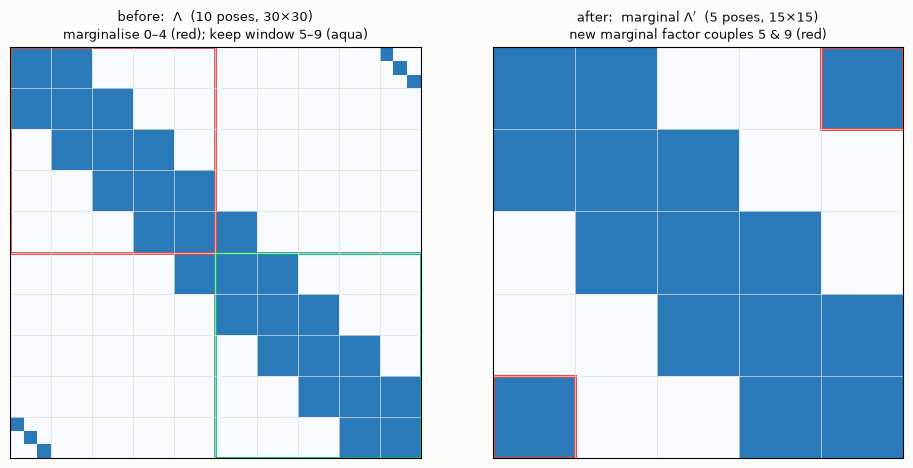

the system shrank from 30x30 to 15x15: poses 0-4 are gone, replaced by one marginal factor now coupling the window's endpoints (5 and 9) that no measurement created.


In [12]:
from matplotlib.patches import Rectangle

# what marginalisation does to the matrix: the old poses' rows/cols vanish, and a new
# marginal factor appears, coupling the window poses that bordered the removed stretch.
fig, (axA, axB) = plt.subplots(1, 2, figsize=(9.8, 4.7), facecolor="#fcfcfb")

axA.imshow(np.abs(Lam) > 1e-12, cmap="Blues", vmin=0, vmax=1.4)
for s in range(0, 3 * K + 1, 3):
    axA.axhline(s - 0.5, color=GRID, lw=0.5); axA.axvline(s - 0.5, color=GRID, lw=0.5)
m = 3 * (K - W)                                                   # boundary: marginalised | window
axA.add_patch(Rectangle((-0.5, -0.5), m, m, fill=False, edgecolor=RED, lw=2))
axA.add_patch(Rectangle((m - 0.5, m - 0.5), 3 * W, 3 * W, fill=False, edgecolor=AQUA, lw=2))
axA.set_title(f"before:  $\\Lambda$  ({K} poses, {3*K}$\\times${3*K})"
              "\nmarginalise 0–4 (red); keep window 5–9 (aqua)", color=INK, fontsize=9.5)
axA.set_xticks([]); axA.set_yticks([])

axB.imshow(np.abs(Lam2) > 1e-12, cmap="Blues", vmin=0, vmax=1.4)
for s in range(0, 3 * W + 1, 3):
    axB.axhline(s - 0.5, color=GRID, lw=0.5); axB.axvline(s - 0.5, color=GRID, lw=0.5)
axB.add_patch(Rectangle((3 * (W - 1) - 0.5, -0.5), 3, 3, fill=False, edgecolor=RED, lw=2.2))
axB.add_patch(Rectangle((-0.5, 3 * (W - 1) - 0.5), 3, 3, fill=False, edgecolor=RED, lw=2.2))
axB.set_title(f"after:  marginal $\\Lambda'$  ({W} poses, {3*W}$\\times${3*W})"
              "\nnew marginal factor couples 5 & 9 (red)", color=INK, fontsize=9.5)
axB.set_xticks([]); axB.set_yticks([])
plt.tight_layout(); plt.show()

print(f"the system shrank from {3*K}x{3*K} to {3*W}x{3*W}: poses 0-4 are gone, replaced by one "
      "marginal factor now coupling the window's endpoints (5 and 9) that no measurement created.")

Three questions answered by that one operation — and one catch that motivates §5.

**Is it really one dense factor, and does the matrix shrink?** Yes to both. Marginalising $x_d$ literally deletes its rows and columns from $\Lambda$, so the system gets *smaller* — the figure above shrinks it from $30\times30$ to $15\times15$. In place of the deleted variable sits **a single new factor** tying all of $x_d$'s former neighbours together, holding the $(\Lambda',\eta')$ we computed. Here it couples the window's two endpoints (poses 5 and 9) that bordered the marginalised stretch; when a variable has many neighbours the factor becomes a full **dense clique** among them. In a fixed-lag window that accumulated factor is the **dense prior** on the oldest surviving pose(s) — all of history, summarised in one block. In the graph it is drawn as that one factor spanning those poses; the old variable node and its measurement factors are gone, replaced by this summary.

**Why "smoothing", and why "fixed-lag"?** A **filter** (the EKF of M0) keeps only the *current* state, marginalising each past pose the instant the next arrives — so an old estimate can never be revisited. A **smoother** keeps a *window of poses and solves them jointly*, so a new measurement still refines earlier poses in the window (a loop closure nudges the whole window, not just the newest pose); that backward refinement is what *smoothing* means. **Fixed-lag** means the window has a *fixed length* $L$ — always keep the most recent $L$ poses, marginalise anything older. That knob spans the two extremes: $L=1$ is a filter, $L=\infty$ is the full batch smoother of M4, and a fixed $L$ is what makes the per-step cost *constant* no matter how long the robot drives.

**The catch — and what §5 brings.** Everything above was *exact* only because we treated the system as linear. Real factors are nonlinear and we linearise them at the current estimate; marginalisation then **freezes that linearisation** into the marginal factor. But $x_d$ is gone, so if the surviving poses later move — and would be better linearised elsewhere — we **cannot relinearise** the information locked in the marginal. Its error is permanent, and a late loop closure onto a marginalised pose can never correct it. That is the price of a bounded window, and it is exactly why a fixed-lag smoother is less accurate than full batch. **§5 keeps every variable instead of marginalising** — bounding the cost of each update through the *structure* of the Bayes tree rather than by discarding history — so every variable stays relinearisable. It recovers the accuracy fixed-lag trades away while keeping updates cheap: that combination is iSAM2.

## 5 · Incremental updates, in and out of order

The batch solve throws the whole problem away and re-factorises from scratch every time a measurement arrives — fine for ten poses, absurd for a robot that runs for hours. **Incremental smoothing** (iSAM) reuses the factorisation it already has and edits only the part a new measurement can reach.

Here is the mechanism, in Bayes-tree terms (§3). Adding a factor between variables $a$ and $b$ changes only the conditionals that involve $a$, $b$, or anything eliminated after them — that is, the cliques on the **path from $a$ and $b$ up to the root** of the tree. Everything below those cliques is untouched. So an update is three local steps: **detach that sub-tree, drop the new factor in, and re-eliminate just those cliques**. The cost is the size of the affected sub-tree, not the whole graph — and because the newest pose sits near the root, a routine odometry step touches only a clique or two.

The figure makes "affected sub-tree" literal — a routine odometry edit versus a loop closure, drawn on a plain chain's Bayes tree:

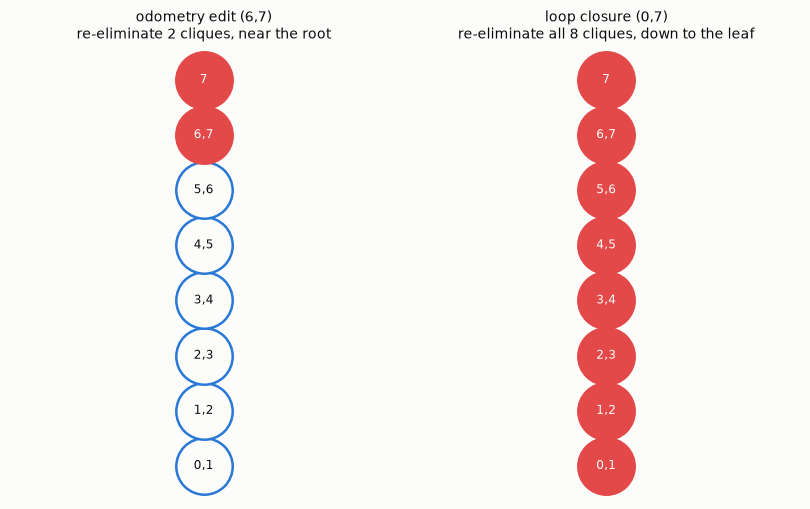

a local measurement re-touches a small sub-tree near the root; a loop closure reaches the leaf, so its sub-tree is the whole chain — the split the cost profile below shows.


In [13]:
def affected(order, touched):
    """Variables (hence cliques) an incremental update must re-eliminate: everything
    from the earliest touched variable up to the root of the Bayes tree."""
    pos = {v: i for i, v in enumerate(order)}
    lo = min(pos[t] for t in touched)
    return [v for v in order if pos[v] >= lo]

# a plain 8-pose chain Bayes tree (clearest case): {0,1} <- {1,2} <- ... <- {6,7} <- {7}
nch = 8
chain_adj = {k: set() for k in range(nch)}
for k in range(nch - 1):
    chain_adj[k].add(k + 1); chain_adj[k + 1].add(k)
corder = list(range(nch))
ctree = bayes_tree(chain_adj, corder)                    # reuse the §3 builder
depth = {}
for v in corder:
    d, p = 0, ctree[v][1]
    while p is not None:
        d += 1; p = ctree[p][1]
    depth[v] = d
maxd = max(depth.values())

def draw_tree(ax, hot, title):
    for v in corder:
        par = ctree[v][1]
        if par is not None:
            ax.plot([0, 0], [maxd - depth[v], maxd - depth[par]], color=GRID, lw=1.3, zorder=1)
    for v in corder:
        y, on = maxd - depth[v], v in hot
        ax.scatter(0, y, s=1650, color=RED if on else "#fcfcfb",
                   edgecolor=RED if on else BLUE, lw=1.8, zorder=2)
        ax.annotate(",".join(map(str, ctree[v][0])), (0, y), ha="center", va="center",
                    color="white" if on else INK, fontsize=8.5, zorder=3)
    ax.set_title(title, color=INK, fontsize=10); ax.axis("off")
    ax.set_xlim(-1.1, 1.1); ax.set_ylim(-0.6, maxd + 0.6)

fig, (axA, axB) = plt.subplots(1, 2, figsize=(8.2, 5.2), facecolor="#fcfcfb")
rec = set(affected(corder, {nch - 2, nch - 1}))          # recent odometry edit (6, 7)
lp  = set(affected(corder, {0, nch - 1}))                # loop closure (0, 7)
draw_tree(axA, rec, f"odometry edit (6,7)\nre-eliminate {len(rec)} cliques, near the root")
draw_tree(axB, lp,  f"loop closure (0,7)\nre-eliminate all {len(lp)} cliques, down to the leaf")
plt.tight_layout(); plt.show()
print("a local measurement re-touches a small sub-tree near the root; a loop closure reaches "
      "the leaf, so its sub-tree is the whole chain — the split the cost profile below shows.")

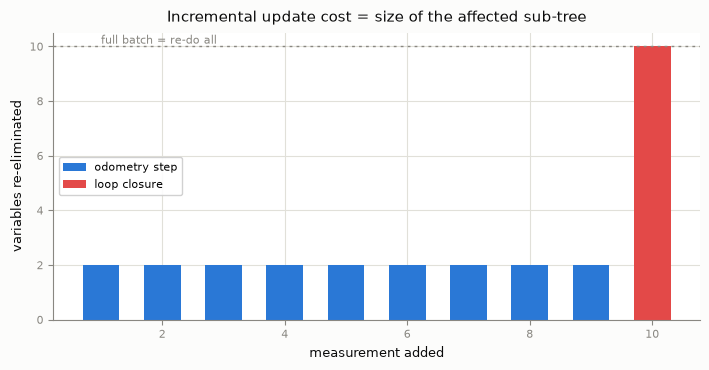

odometry updates re-eliminate 2 variables each; the loop closure re-eliminates 10 of 10 - the classic iSAM cost profile.


In [14]:
order = list(range(K))
# stream the trajectory: when pose k arrives, only poses 0..k exist, and the new
# odometry factor (k-1, k) sits at the top of the tree -> only the two newest re-eliminate.
per_step = []
for k in range(1, K):
    per_step.append(len(affected(list(range(k + 1)), {k - 1, k})))
loop_cost = len(affected(order, {0, K - 1}))              # a loop closure reaches all the way back to pose 0

fig, ax = plt.subplots(figsize=(7.2, 3.8), facecolor="#fcfcfb")
ax.bar(range(1, K), per_step, color=BLUE, width=0.6, label="odometry step")
ax.bar([K], [loop_cost], color=RED, width=0.6, label="loop closure")
ax.axhline(K, color=MUTED, lw=1, ls=(0, (2, 3)))
ax.annotate("full batch = re-do all", (1, K), color=MUTED, fontsize=8, va="bottom")
_style(ax, "Incremental update cost = size of the affected sub-tree")
ax.set_xlabel("measurement added", color=INK, fontsize=9)
ax.set_ylabel("variables re-eliminated", color=INK, fontsize=9)
ax.legend(fontsize=8, framealpha=0.9); plt.tight_layout(); plt.show()

print("odometry updates re-eliminate", per_step[0], "variables each;",
      "the loop closure re-eliminates", loop_cost, "of", K, "- the classic iSAM cost profile.")

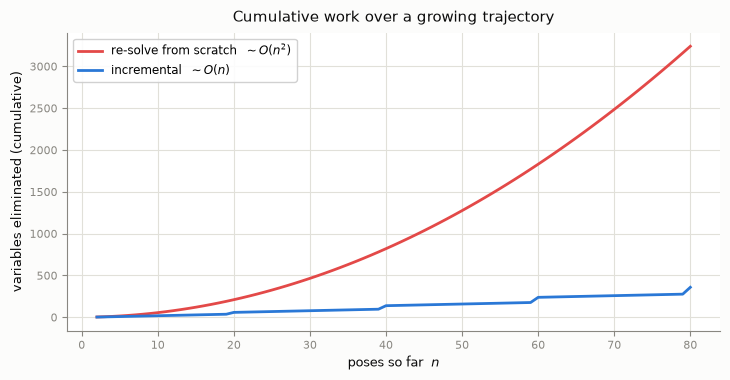

re-solving from scratch is quadratic in trajectory length; incremental stays linear (with a bump at each loop closure) — the whole reason SLAM back-ends are incremental.


In [15]:
# why incremental matters at scale: cumulative work as the trajectory grows.
lengths = np.arange(2, 81)
batch_work = lengths * (lengths + 1) // 2                # re-solve all n vars, each of n steps -> O(n^2)
incr_work, tot = [], 0
for n in lengths:
    tot += 2                                             # a routine odometry step: a clique or two
    if n % 20 == 0:
        tot += int(n)                                    # an occasional loop closure: back to the leaf
    incr_work.append(tot)
incr_work = np.array(incr_work)

fig, ax = plt.subplots(figsize=(7.4, 3.9), facecolor="#fcfcfb")
ax.plot(lengths, batch_work, color=RED, lw=2, label=r"re-solve from scratch  $\sim O(n^2)$")
ax.plot(lengths, incr_work,  color=BLUE, lw=2, label=r"incremental  $\sim O(n)$")
_style(ax, "Cumulative work over a growing trajectory")
ax.set_xlabel(r"poses so far  $n$", color=INK, fontsize=9)
ax.set_ylabel("variables eliminated (cumulative)", color=INK, fontsize=9)
ax.legend(fontsize=8.5, framealpha=0.9); plt.tight_layout(); plt.show()
print("re-solving from scratch is quadratic in trajectory length; incremental stays linear "
      "(with a bump at each loop closure) — the whole reason SLAM back-ends are incremental.")

**Out of order is free.** Nothing above assumed measurements arrive in trajectory order. A loop closure ties the *newest* pose to a very *old* one; a delayed GPS fix lands on a pose from minutes ago. Either way the update rule is identical — re-eliminate the affected set — and the result is bit-for-bit the batch answer. This is the "latency-rewind" an ad-hoc filter has to bolt on by hand; here it is just how elimination works.

In [16]:
# add a late, out-of-order loop closure to the already-built graph and re-solve two ways.
Lam_l, eta_l, sl_l = system(pose_graph(loop=True), values)     # graph now includes the loop factor
batch = np.linalg.solve(Lam_l, eta_l)
incr, _ = eliminate(Lam_l, eta_l, sl_l, order=min_degree_order(var_adjacency(pose_graph(True), list(range(K)))))
print("out-of-order loop closure — incremental elimination vs batch:", np.max(np.abs(batch - incr)))
assert np.allclose(batch, incr, atol=1e-9)
print("identical. The order measurements arrive in never changes the answer, only the work.")

out-of-order loop closure — incremental elimination vs batch: 1.3183898417423734e-16
identical. The order measurements arrive in never changes the answer, only the work.


**Relinearisation — the nonlinear half.** Everything above kept the system linear, so "re-eliminate the affected set" was the whole story. But real factors are nonlinear: each is linearised at the current estimate, and when a new measurement moves a variable, the factors touching it are now linearised at the *wrong* point. Because incremental smoothing **keeps every variable** — unlike §4's marginalisation, which froze and discarded them — it can simply **relinearise** them at the new estimate and re-eliminate; nothing is locked. iSAM2's refinement is to do this *selectively*: **fluid relinearisation** re-linearises only the variables whose estimate shifted past a threshold, and rebuilds only their cliques. That is what buys back the accuracy §4 gave away — the marginal is never frozen — while keeping the work per update proportional to what actually changed. **Structural locality (this section) + fluid relinearisation = iSAM2.**

## 6 · Tie-back: this is iSAM2

Put the pieces together and you have the skeleton of the algorithm the rest of robotics runs on:

- **Sparsity** (§1) — the information matrix mirrors the factor graph; almost everything is zero.
- **Variable elimination** (§2) — factorise by removing one variable at a time; each step is a Schur complement. Fill-in is the only enemy.
- **Ordering + the Bayes tree** (§3) — a good elimination order (minimum degree / COLAMD) keeps fill-in small, and the elimination induces a **Bayes tree** whose structure localises everything that follows.
- **Marginalization** (§4) — Schur-complement old variables out for a bounded-cost fixed-lag smoother, at the price of freezing their linearisation.
- **Incremental updates** (§5) — a new factor only re-eliminates its affected sub-tree; out-of-order measurements are free.

**iSAM2** is exactly this, made *fluid*: it stores the Bayes tree, and when a measurement arrives it edits only the affected cliques **and relinearises just those variables whose estimate moved enough to matter** (fluid relinearisation) — keeping the accuracy of batch smoothing at the cost of a filter. You will not re-implement its tree surgery here; you have built every idea it rests on.

**Where this goes next.** M6 stops rebuilding and picks up **GTSAM**: `NonlinearFactorGraph`, `ISAM2`, `Marginals` — mapping each object you just built onto the library the production system will use, and reproducing these very results.

## Appendix A · Elimination *is* Cholesky

Variable elimination and Cholesky factorisation are the same computation in two languages. Cholesky writes $\Lambda = R^\top R$ with $R$ upper-triangular; eliminating variable $v$ (Schur-complementing it out) produces exactly one block-row of $R$ — the conditional $x_v \mid x_N$ — and the updated remaining system is the trailing submatrix still to be factorised. The elimination **order** is the Cholesky **variable ordering**; the **fill-in** is precisely the non-zeros in $R$ that are not in $\Lambda$. So "reorder to reduce fill-in" (this module) and "reorder for a sparse Cholesky factor" (numerical linear algebra) are one statement. Below: eliminate, reassemble $R$, and confirm $R^\top R = \Lambda$.

In [17]:
# reconstruct the Cholesky factor R from the elimination conditionals and check R^T R = Lambda
def chol_from_elim(Lam, slices, order):
    L = Lam.copy(); active = set(order); n = Lam.shape[0]
    R = np.zeros((n, n))
    for v in order:
        sv = slices[v]
        neigh = [u for u in active if u != v and np.any(L[sv, slices[u]])]
        Rvv = np.linalg.cholesky(L[sv, sv]).T                 # upper-triangular block on the diagonal
        R[sv, sv] = Rvv
        Rinv = np.linalg.inv(Rvv)
        for u in neigh:
            R[sv, slices[u]] = Rinv.T @ L[sv, slices[u]]      # off-diagonal blocks of R
        for u in neigh:                                       # Schur complement (as before)
            Luv = L[slices[u], sv]; Ainv = np.linalg.inv(L[sv, sv])
            for w in neigh:
                L[slices[u], slices[w]] -= Luv @ Ainv @ L[sv, slices[w]]
        active.discard(v)
    return R

R = chol_from_elim(Lam, slices, list(range(K)))
print("max |R^T R - Lambda| =", np.max(np.abs(R.T @ R - Lam)))
assert np.allclose(R.T @ R, Lam, atol=1e-8)
print("elimination reproduces the Cholesky factor exactly.")

max |R^T R - Lambda| = 1.8189894035458565e-12
elimination reproduces the Cholesky factor exactly.


## Appendix B · The Schur complement is marginalization

Splitting the joint information over kept variables $k$ and dropped variables $d$,

$$\begin{bmatrix}\Lambda_{kk} & \Lambda_{kd}\\ \Lambda_{dk} & \Lambda_{dd}\end{bmatrix}\begin{bmatrix}\delta_k\\ \delta_d\end{bmatrix}=\begin{bmatrix}\eta_k\\ \eta_d\end{bmatrix},$$

solve the second block-row for $\delta_d = \Lambda_{dd}^{-1}(\eta_d - \Lambda_{dk}\delta_k)$ and substitute into the first. What remains is a system on $\delta_k$ alone with

$$\Lambda_k' = \Lambda_{kk} - \Lambda_{kd}\Lambda_{dd}^{-1}\Lambda_{dk}, \qquad \eta_k' = \eta_k - \Lambda_{kd}\Lambda_{dd}^{-1}\eta_d.$$

That $(\Lambda_k', \eta_k')$ is the **marginal** — it is what `marginalize` computes in §4, and it is one elimination step with the conditional thrown away rather than kept. Eliminate-and-keep gives a factorisation (§2); eliminate-and-drop gives a marginal (§4). Same subtraction, two uses.